In [39]:
import torch
import utils
import matplotlib.pyplot as plt
from collections import Counter
import random
import math

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
def explore_dataset(dataset="cifar", data_path="../../data/"):

    if dataset == "cifar":
        data_path = utils.check_cifar_dataset_exists(data_path)
    elif dataset == "mnist":
       data_path = utils.check_mnist_dataset_exists(data_path)
    elif dataset == "cifar100":
        data_path = utils.check_cifar100_dataset_exists(data_path)
    else:
        raise ValueError(f"Dataset '{dataset}' not supported in explore_dataset().")

    train_x, train_y = (torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True))

    test_x, test_y = (torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True))

    print("Number of Training Samples:", len(train_x))
    print("Number of Test Samples:", len(test_x))

    num_channels = 1

    if len(train_x.size())==4:
        num_channels=train_x.size(1)

    img_size = train_x.size(-1)

    num_classes = train_y.unique().size(0)

    print(f"Image size: {img_size}")
    print(f"Number of channels: {num_channels}")
    print(f"Number of classes:  {num_classes}")

    counts = Counter(train_y.tolist())
    plt.bar(counts.keys(), counts.values())
    plt.title(f"{dataset} Train Set Class Distribution")

    counts = Counter(test_y.tolist())
    plt.bar(counts.keys(), counts.values())
    plt.title(f"{dataset} Test Set Class Distribution")

    plt.legend(["Train", "Test"])

    # Show 1 image per class
    # Sample either all classes or 10 random ones
    preview_samples = torch.arange(num_classes) if num_classes <= 10 else torch.randint(0, num_classes, (10,))
    num_preview = len(preview_samples)

    cols = math.ceil(num_preview / 2)
    rows = 2

    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    for i, class_id in enumerate(preview_samples):
        class_id = class_id.item()

        indices = (train_y == class_id).nonzero(as_tuple=True)[0]
        rand_idx = random.choice(indices).item()
        image = train_x[rand_idx]

        plt.subplot(rows, cols, i + 1)
        if num_channels == 1:
            plt.imshow(image.squeeze(0), cmap="gray")
        else:
            plt.imshow(image.permute(1, 2, 0))
        plt.title(f"Class {class_id}")
        plt.axis("off")

    plt.suptitle("Random Image per Class (up to 10 shown)")
    plt.tight_layout()
    plt.show()


    plt.tight_layout()
    plt.show()


Number of Training Samples: 50000
Number of Test Samples: 10000
Image size: 32
Number of channels: 3
Number of classes:  10


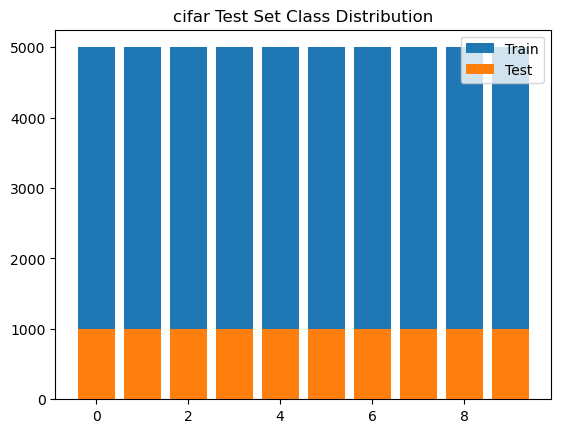

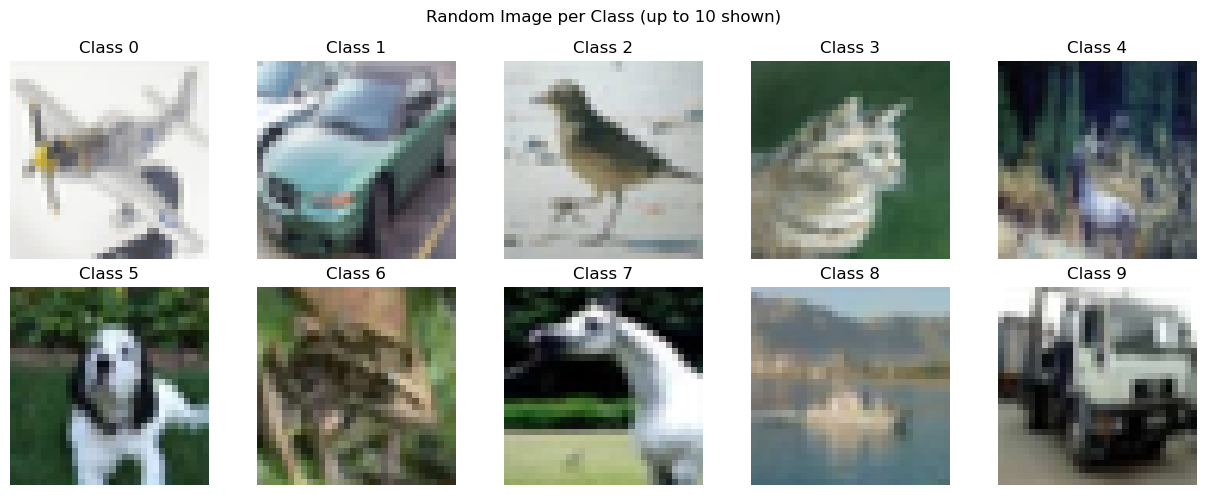

<Figure size 640x480 with 0 Axes>

In [50]:
explore_dataset(dataset="cifar")

Number of Training Samples: 50000
Number of Test Samples: 10000
Image size: 32
Number of channels: 3
Number of classes:  100


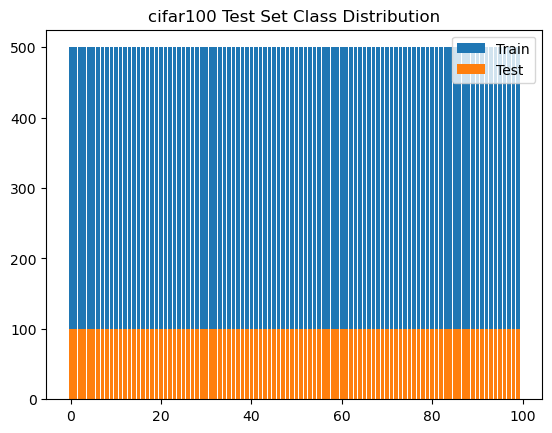

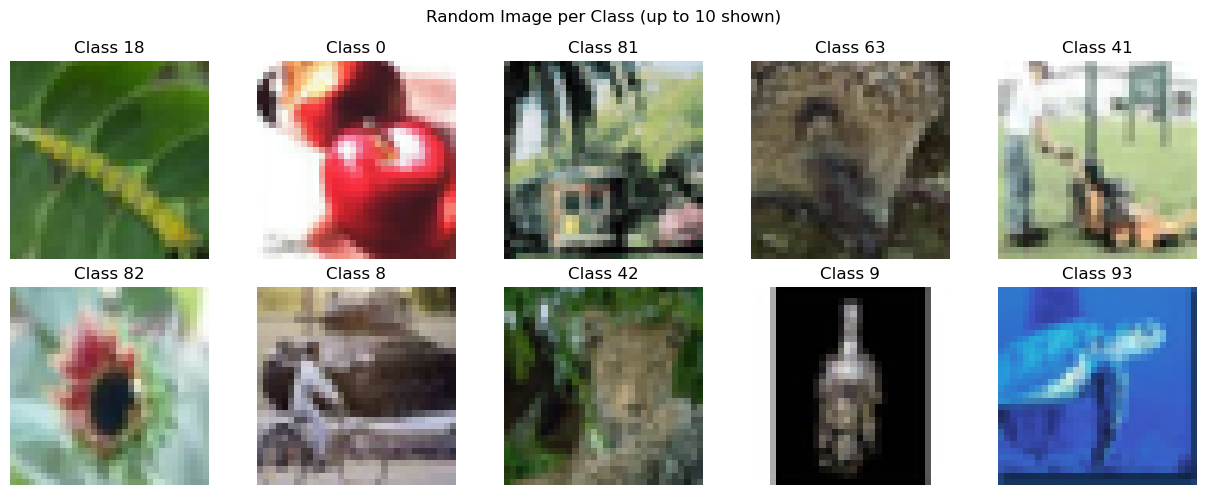

<Figure size 640x480 with 0 Axes>

In [51]:
explore_dataset("cifar100")

Number of Training Samples: 60000
Number of Test Samples: 10000
Image size: 28
Number of channels: 1
Number of classes:  10


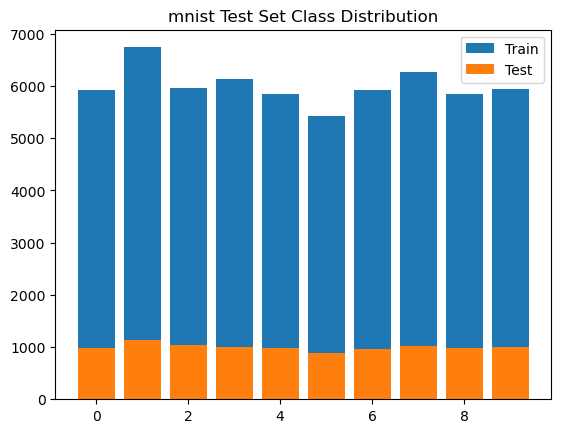

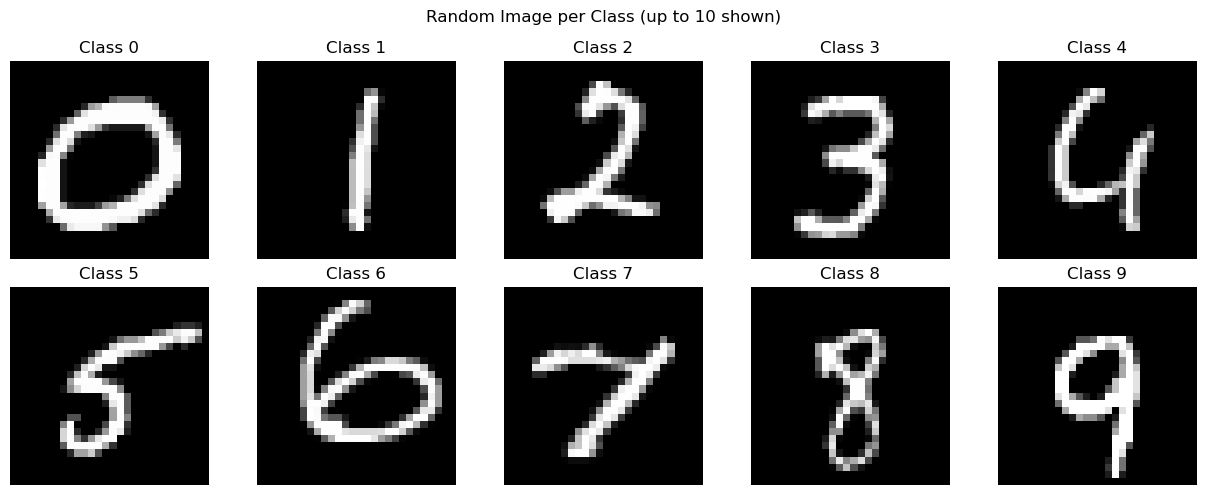

<Figure size 640x480 with 0 Axes>

In [52]:
explore_dataset(dataset="mnist")

In [20]:
# import torch
# import matplotlib.pyplot as plt
# from collections import Counter
# import random
# import torchvision.transforms as T
#
# def explore_dataset(dataset="cifar", data_path="../../data/"):
#
#     # --- Path check ---
#     if dataset == "cifar":
#         data_path = utils.check_cifar_dataset_exists(data_path)
#     elif dataset == "mnist":
#         data_path = utils.check_mnist_dataset_exists(data_path)
#     elif dataset == "cifar100":
#         data_path = utils.check_cifar100_dataset_exists(data_path)
#     else:
#         raise ValueError(f"Dataset '{dataset}' not supported in explore_dataset().")
#
#     # --- Load data ---
#     train_x = torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True)
#     train_y = torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True)
#     test_x  = torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True)
#     test_y  = torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True)
#
#     print("Number of Training Samples:", len(train_x))
#     print("Number of Test Samples:", len(test_x))
#
#     num_channels = train_x.size(1) if train_x.ndim == 4 else 1
#     img_size = train_x.size(-1)
#     num_classes = train_y.unique().size(0)
#
#     print(f"Image size: {img_size}x{img_size}")
#     print(f"Number of channels: {num_channels}")
#     print(f"Number of classes: {num_classes}")
#
#     # --- Class distribution ---
#     plt.figure(figsize=(6, 4))
#     counts = Counter(train_y.tolist())
#     plt.bar(counts.keys(), counts.values())
#     plt.title(f"{dataset.upper()} Class Distribution")
#     plt.xlabel("Class ID")
#     plt.ylabel("Frequency")
#     plt.tight_layout()
#     plt.show()
#
#     # --- Random image per class ---
#     plt.figure(figsize=(15, 6))
#     for class_id in range(num_classes):
#         indices = (train_y == class_id).nonzero(as_tuple=True)[0]
#         rand_idx = random.choice(indices).item()
#         image = train_x[rand_idx]
#
#         plt.subplot(2, (num_classes + 1) // 2, class_id + 1)
#         if num_channels == 1:
#             plt.imshow(image.squeeze(0), cmap="gray")
#         else:
#             plt.imshow(image.permute(1, 2, 0))
#         plt.title(f"Class {class_id}")
#         plt.axis("off")
#     plt.suptitle("One Random Image per Class")
#     plt.tight_layout()
#     plt.show()
#
#     # --- Pixel intensity distribution ---
#     plt.figure(figsize=(6, 4))
#     flat = train_x.float().view(train_x.size(0), -1) / 255.0
#     plt.hist(flat.mean(dim=1).numpy(), bins=30, color="orange")
#     plt.title("Mean Pixel Intensity per Image")
#     plt.xlabel("Mean Intensity (0-1)")
#     plt.ylabel("Image Count")
#     plt.tight_layout()
#     plt.show()
#
#
#     # --- Example: Augmentation preview ---
#     transform = T.Compose([
#         T.RandomCrop(img_size, padding=4),
#         T.RandomHorizontalFlip()
#     ])
#
#     plt.figure(figsize=(6, 3))
#     idx = random.randint(0, len(train_x) - 1)
#     orig = train_x[idx]
#     aug = transform(orig)
#
#     plt.subplot(1, 2, 1)
#     plt.imshow(orig.permute(1, 2, 0) if num_channels > 1 else orig.squeeze(0), cmap="gray")
#     plt.title("Original")
#     plt.axis("off")
#
#     plt.subplot(1, 2, 2)
#     plt.imshow(aug.permute(1, 2, 0) if num_channels > 1 else aug.squeeze(0), cmap="gray")
#     plt.title("Augmented")
#     plt.axis("off")
#
#     plt.suptitle("Augmentation Preview")
#     plt.tight_layout()
#     plt.show()
#
#     # Optional: t-SNE or PCA projection (skip unless needed — compute-heavy)
#     # You can use sklearn TSNE or PCA on flattened and sampled image set
